In [1]:
import os
import numpy as np
import yaml
import matplotlib.pyplot as plt
import healpy as hp
import heracles
import heracles.dices as dices
from heracles.io import read
from astropy.io import fits

font = {'size'   : 16}
import matplotlib
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=12) 
matplotlib.rc('ytick', labelsize=12) 

# Comparison

## Masks

In [2]:
config_path = "scripts/sims_config.yaml"
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)
n = 10 #config['nsims']
nside = 1024
lmax_partial = config['lmax_partial']
lmax_full = config['lmax_full']
lmin = config['lmin']
lmax_mask = config.get('lmax_mask')  # Default to lmax if not specified
mode = "lognormal" #config['mode']  # "lognormal" or "gaussian"
mask_type = "tr1" #config['mask_type']  # Default to 'dr1' if not specified
binned = False #True
apply_mask = True
opt_method = "wass"
nbins = 3

output_path = f"{mode}_dices/"
output_path = "./masked_"+output_path

nlbins = config.get('nlbins', 20)  # Default to 20 if not specified
l = np.arange(lmax_partial+1)
l_mask = np.arange(lmax_mask+1)
ledges = np.logspace(np.log10(lmin), np.log10(lmax_full), nlbins + 1)
lgrid = (ledges[1:] + ledges[:-1]) / 2
ledges_mask = np.logspace(np.log10(lmin), np.log10(lmax_mask), nlbins + 1)
lgrid_mask = (ledges_mask[1:] + ledges_mask[:-1]) / 2

In [3]:
from astropy.io import fits
from scipy.ndimage import gaussian_filter1d

z = np.linspace(0.0, 3, 3000)
nzs_wl_hdul = fits.open("/pscratch/sd/j/jaimerz/lognormal_sims/TR1_v1_Nz_WL_C2020_sel_pv.fits")
nzs_wl = gaussian_filter1d(nzs_wl_hdul[1].data["N_Z"].T, 10, axis=0)


In [4]:
print(z.shape, nzs_wl.shape)

(3000,) (3000, 6)


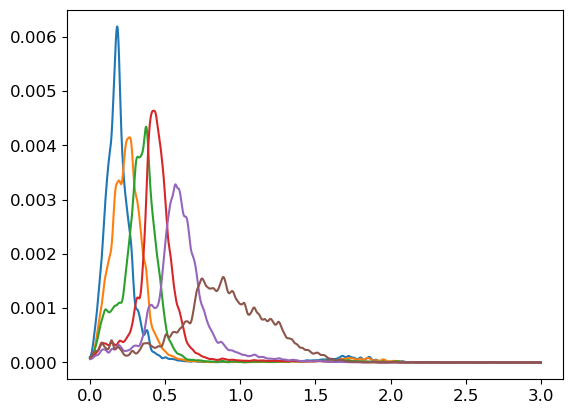

In [5]:
plt.plot(z, nzs_wl)
plt.show()

In [6]:
# make a cosmology
if False:
    import camb
    import camb.sources
    
    h = 0.67
    Om = 0.319
    Ob = 0.049
    Oc = Om - Ob
    pars = camb.set_params(
        H0=100 * h,
        omch2=Oc * h**2,
        ombh2=Ob * h**2,
        NonLinear=camb.model.NonLinear_both,
    )
    
    pars.set_accuracy(AccuracyBoost=2.0, lAccuracyBoost=2.0, lSampleBoost=2.0)
    pars.Want_CMB = False
    pars.Want_CMB_lensing = False
    pars.min_l = 1
    pars.set_for_lmax(2 * lmax_partial)
    pars.SourceWindows = [camb.sources.SplinedSourceWindow(z=z, W=nz_i, source_type="lensing") for nz_i in nzs_wl.T]
    cls_dict = camb.get_results(pars).get_source_cls_dict(lmax=lmax_partial, raw_cl=True)

    results = {}
    for key in cls_dict.keys():
        results[key] = heracles.Result(cls_dict[key])
    heracles.write("/pscratch/sd/j/jaimerz/lognormal_sims/theory_camb.fits", results)

In [7]:
theory_cls = heracles.read("/pscratch/sd/j/jaimerz/lognormal_sims/theory_camb.fits")

In [28]:
sim = heracles.read_maps(f"/pscratch/sd/j/jaimerz/lognormal_sims/lognormal_sim_3_nside_{nside}/SHE.fits")
sim_wb = heracles.read_maps(f"/pscratch/sd/j/jaimerz/lognormal_sims/lognormal_sim_3_nside_{nside}/SHE_wb.fits")
mask = hp.read_map(f"/pscratch/sd/j/jaimerz//masks/tr1_mask_nside_{nside}.fits")
fsky=np.sum(mask)/len(mask)
print(fsky)

0.009183009465535482


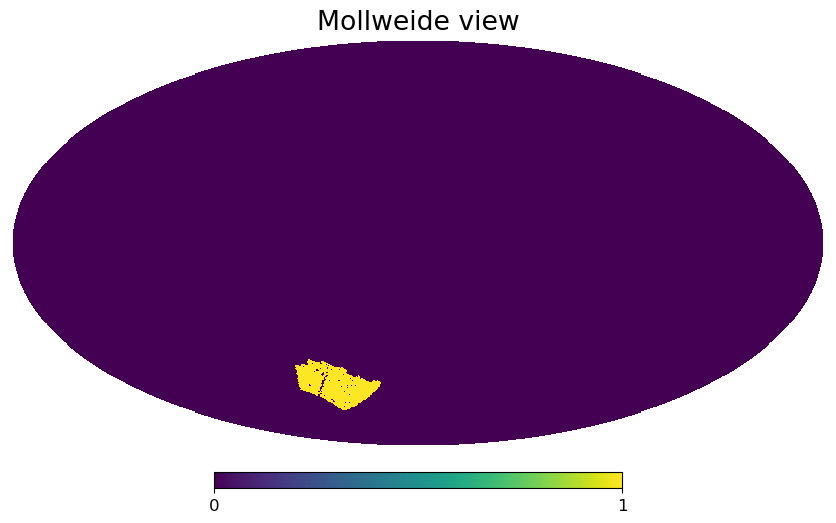

In [29]:
hp.mollview(mask)

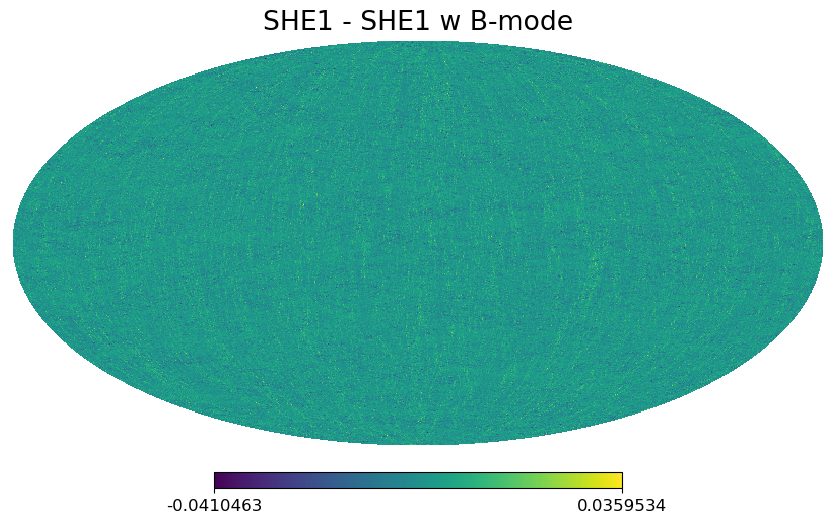

In [30]:
hp.mollview(sim["SHE", 4][0], title="SHE1 - SHE1 w B-mode")

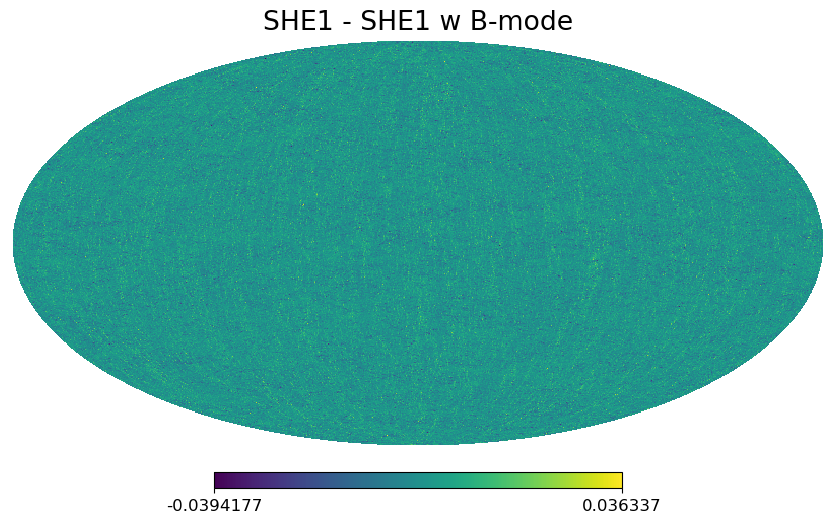

In [31]:
hp.mollview(sim_wb["SHE", 4][0], title="SHE1 - SHE1 w B-mode")

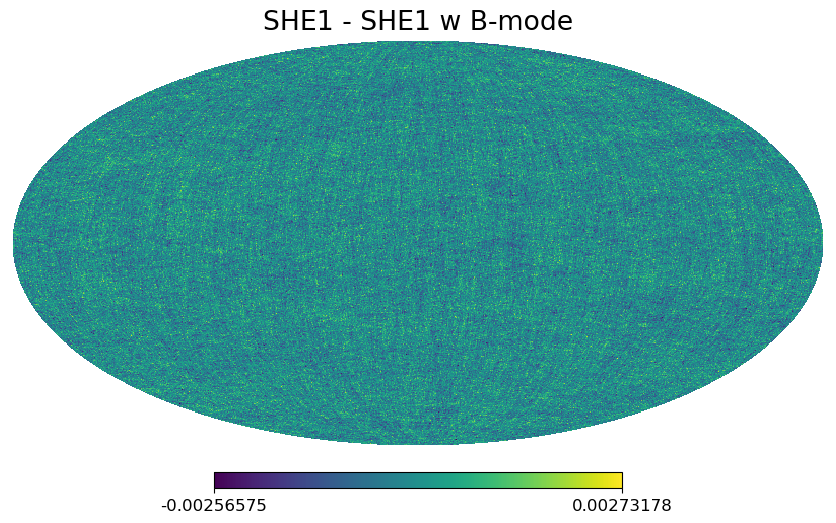

In [32]:
hp.mollview(sim["SHE", 1][1]-sim_wb["SHE", 1][1], title="SHE1 - SHE1 w B-mode")

In [33]:
sims = [heracles.read_maps(f"/pscratch/sd/j/jaimerz/lognormal_sims/lognormal_sim_{i}_nside_{nside}/SHE.fits")["SHE", 2][0] for i in range(1, 10+1)]
sims_wb = [heracles.read_maps(f"/pscratch/sd/j/jaimerz/lognormal_sims/lognormal_sim_{i}_nside_{nside}/SHE_wb.fits")["SHE", 2][0] for i in range(1, 10+1)]

In [34]:
sims_s = np.std(sims, axis=0)
sims_wb_s = np.std(sims_wb, axis=0)

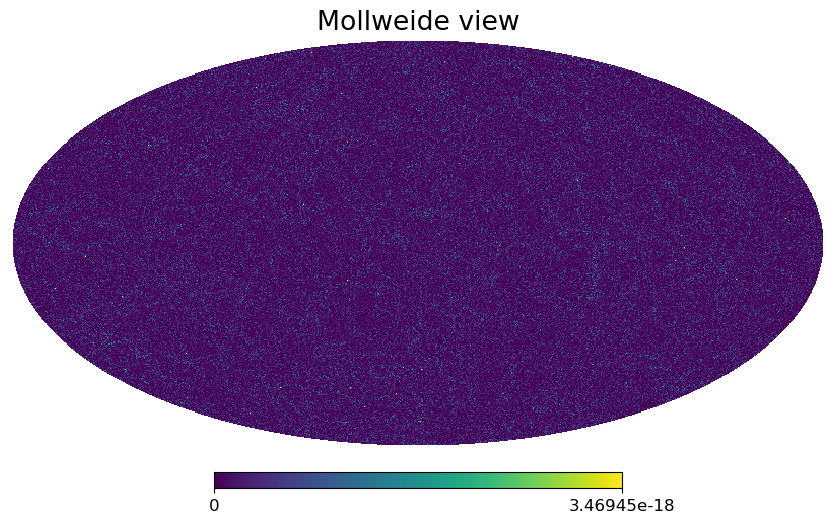

In [35]:
hp.mollview(sims_s)

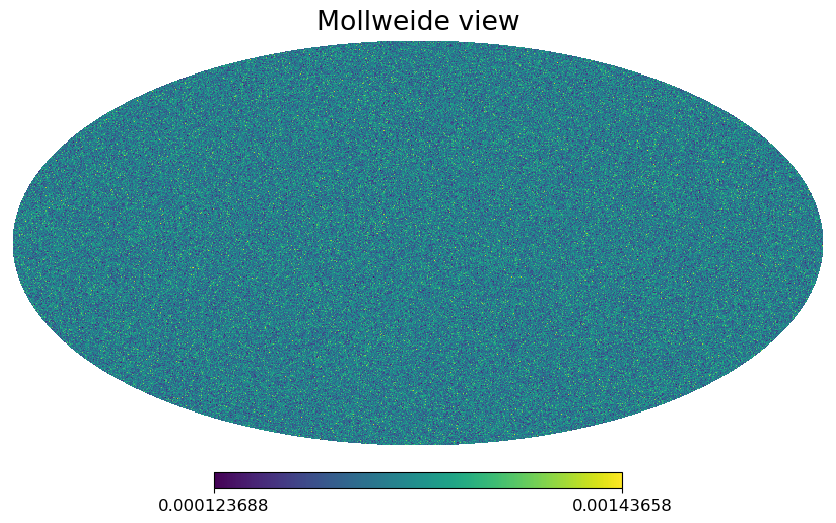

In [36]:
hp.mollview(sims_wb_s)

## Cls

In [21]:
## full-sky
path = f"/pscratch/sd/j/jaimerz/{mode}_sims/fullsky/"
fullsky_cls = {}
fullsky_cls_wb = {}
for i in range(1, 3+1):
    print(f"Loading sim {i}", end='\r')
    fullsky_cls[i] = heracles.read(path+f"/cls/cls_data_{i}_lmax_{lmax_partial}.fits")
    fullsky_cls_wb[i] = heracles.read(path+f"/cls/cls_data_wb_{i}_lmax_{lmax_partial}.fits")
fullsky_cqs = heracles.binned(fullsky_cls, ledges)
fullsky_cqs_wb = heracles.binned(fullsky_cls_wb, ledges)


Loading sim 3

In [22]:
## TR1
path = f"/pscratch/sd/j/jaimerz/{mode}_sims/tr1/"
tr1_cls = {}
tr1_nu_cls = {}
tr1_cls_wb = {}
tr1_nu_cls_wb = {}
for i in range(1, n+1):
    print(f"Loading sim {i}", end='\r')
    tr1_cls[i] = heracles.read(path+f"/cls/cls_data_{i}_lmax_{lmax_partial}.fits")
    tr1_cls_wb[i] = heracles.read(path+f"/cls/cls_data_wb_{i}_lmax_{lmax_partial}.fits")
    tr1_nu_cls[i] = heracles.read(path+f"/cls_nu/cls_data_nu_{i}_l1max_{lmax_partial}_l2max_{lmax_mask}.fits")
    tr1_nu_cls_wb[i] = heracles.read(path+f"/cls_nu/cls_data_wb_nu_{i}_l1max_{lmax_partial}_l2max_{lmax_mask}.fits")
tr1_cqs = heracles.binned(tr1_cls, ledges)
tr1_cqs_wb = heracles.binned(tr1_cls_wb, ledges)
tr1_nu_cqs = heracles.binned(tr1_nu_cls, ledges)
tr1_nu_cqs_wb = heracles.binned(tr1_nu_cls_wb, ledges)

#tr1_nmt_cqs = {}
#tr1_nmt_cqs_wb = {}
#for i in range(1, n+1):
#    print(f"Loading sim {i}", end='\r')
#    tr1_nmt_cqs[i] = heracles.read(path+f"/cls_nmt/cqs_data_nmt_np_{i}_lmin_{lmin}_lmax_{lmax}.fits")
#    tr1_nmt_cqs_wb[i] = heracles.read(path+f"/cls_nmt/cqs_data_nmt_np_{i}_lmin_{lmin}_lmax_{lmax}_wb.fits")


Loading sim 10

In [23]:
def get_cls_mean(cls_dict):
    n_keys = list(cls_dict.keys())
    f_keys = list(cls_dict[n_keys[0]].keys())
    cls_mean = {}
    for f_key in f_keys:
        cl = np.mean([cls_dict[i][f_key] for i in n_keys], axis=0)
        cls_mean[f_key] = heracles.Result(cl, axis=cls_dict[n_keys[0]][f_key].axis)
    return cls_mean

def get_cls_std(cls_dict):
    n_keys = list(cls_dict.keys())
    f_keys = list(cls_dict[n_keys[0]].keys())
    cls_std = {}
    for f_key in f_keys:
        cl = np.std([cls_dict[i][f_key] for i in n_keys], axis=0)
        cls_std[f_key] = heracles.Result(cl, axis=cls_dict[n_keys[0]][f_key].axis)
    return cls_std

In [24]:
## Full Sky means
fullsky_cls_m, fullsky_cls_s = get_cls_mean(fullsky_cls), get_cls_std(fullsky_cls)
fullsky_cqs_m, fullsky_cqs_s = get_cls_mean(fullsky_cqs), get_cls_std(fullsky_cqs)
fullsky_cls_wb_m, fullsky_cls_wb_s = get_cls_mean(fullsky_cls_wb), get_cls_std(fullsky_cls_wb)
fullsky_cqs_wb_m, fullsky_cqs_wb_s = get_cls_mean(fullsky_cqs_wb), get_cls_std(fullsky_cqs_wb)

## TR1 means
tr1_cls_m, tr1_cls_s = get_cls_mean(tr1_cls), get_cls_std(tr1_cls)
tr1_cqs_m, tr1_cqs_s = get_cls_mean(tr1_cqs), get_cls_std(tr1_cqs)
tr1_cls_wb_m, tr1_cls_wb_s = get_cls_mean(tr1_cls_wb), get_cls_std(tr1_cls_wb)
tr1_cqs_wb_m, tr1_cqs_wb_s = get_cls_mean(tr1_cqs_wb), get_cls_std(tr1_cqs_wb)

tr1_nu_cls_m, tr1_nu_cls_s = get_cls_mean(tr1_nu_cls), get_cls_std(tr1_nu_cls)
tr1_nu_cqs_m, tr1_nu_cqs_s = get_cls_mean(tr1_nu_cqs), get_cls_std(tr1_nu_cqs)
tr1_nu_cls_wb_m, tr1_nu_cls_wb_s = get_cls_mean(tr1_nu_cls_wb), get_cls_std(tr1_nu_cls_wb)
tr1_nu_cqs_wb_m, tr1_nu_cqs_wb_s = get_cls_mean(tr1_nu_cqs_wb), get_cls_std(tr1_nu_cqs_wb)

#tr1_nmt_cqs_m, tr1_nmt_cqs_s = get_cls_mean(tr1_nmt_cqs), get_cls_std(tr1_nmt_cqs)
#tr1_nmt_cqs_wb_m, tr1_nmt_cqs_wb_s = get_cls_mean(tr1_nmt_cqs_wb), get_cls_std(tr1_nmt_cqs_wb)

[]

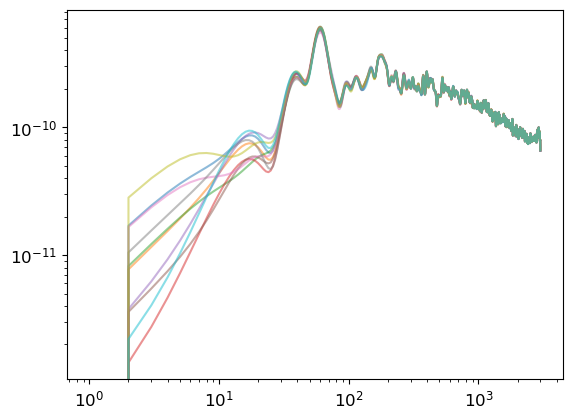

In [25]:
plt.plot(l, np.array([l*tr1_cls_wb[i]["SHE", "SHE", 1, 1][0, 0] for i in range(1, n+1)]).T, alpha=0.5)
plt.loglog()

[]

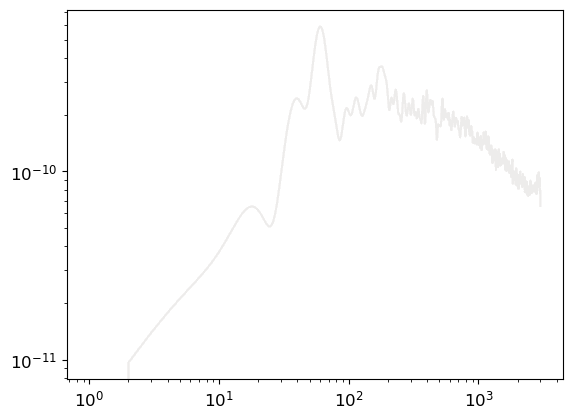

In [26]:
plt.plot(l, np.array([l*tr1_cls[i]["SHE", "SHE", 1, 1][0, 0] for i in range(1, n+1)]).T, alpha=0.01)
plt.loglog()

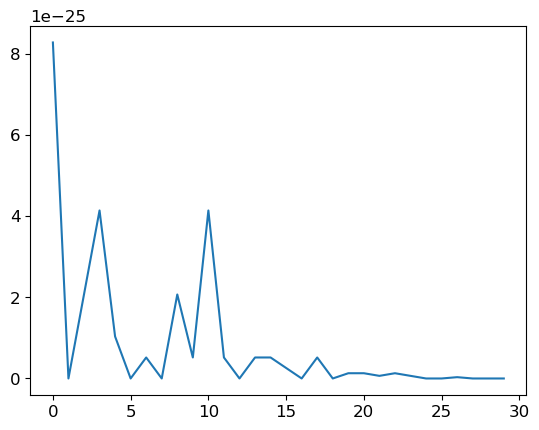

In [27]:
plt.plot(tr1_nu_cqs_s["SHE", "SHE", 1, 1][0, 0])

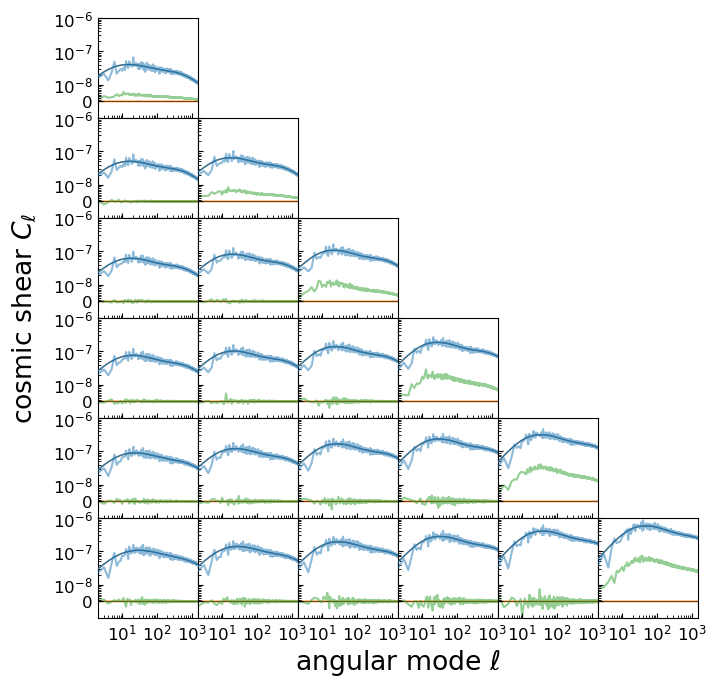

In [61]:
fig, ax = plt.subplots(6, 6, figsize=(6, 6), sharex=True, sharey=True)

for i in range(1, 7):
    for j in range(1, i):
        ax[j - 1, i - 1].axis("off")
    for j in range(i, 7):
        ax[j - 1, i - 1].plot(
            l[2:],
            l[2:]*fullsky_cls_m["SHE", "SHE", i, j][0, 0, 2:],
            c="C0",
            lw=1.5,
            zorder=3.0,
            alpha=0.5,
        )
        ax[j - 1, i - 1].plot(
            l[2:], l[2:]*theory_cls[f"W{i}xW{j}"][2:], c="C0", lw=1.0, zorder=4.0
        )
        ax[j - 1, i - 1].plot(
            l[2:],
            l[2:]*fullsky_cls_m["SHE", "SHE", i, j][1, 1, 2:],
            c="C1",
            lw=1.5,
            zorder=1.0,
            alpha=0.5,
        )
        ax[j - 1, i - 1].plot(
            l[2:],
            l[2:]*fullsky_cls_wb_m["SHE", "SHE", i, j][1, 1, 2:],
            c="C2",
            ls='-',
            lw=1.5,
            zorder=1.0,
            alpha=0.5,
        )
        ax[j - 1, i - 1].plot(
            l[2:], l[2:]*theory_cls[f"W{i}xW{j}"][2:], c="C1", lw=1.0, zorder=2.0
        )
        ax[j - 1, i - 1].axhline(0.0, c="k", lw=0.8, zorder=-1)
        ax[j - 1, i - 1].tick_params(axis="both", which="both", direction="in")

ax[0, 0].set_xscale("log")
ax[0, 0].set_xlim(2, lmax_full)
ax[0, 0].xaxis.get_major_locator().set_params(numticks=99)
ax[0, 0].xaxis.get_minor_locator().set_params(
    numticks=99, subs=np.arange(0.1, 1.0, 0.1)
)
ax[0, 0].set_yscale(
    "symlog", linthresh=1e-8, linscale=0.45, subs=np.arange(0.1, 1.0, 0.1)
)
ax[0, 0].set_ylim(-1e-8, 1e-6)

fig.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=1.0, wspace=0.0, hspace=0.0)

fig.supxlabel("angular mode $\\ell$", y=-0.05, va="top")
fig.supylabel("cosmic shear $C_\\ell$", x=-0.1, ha="right")

plt.show()

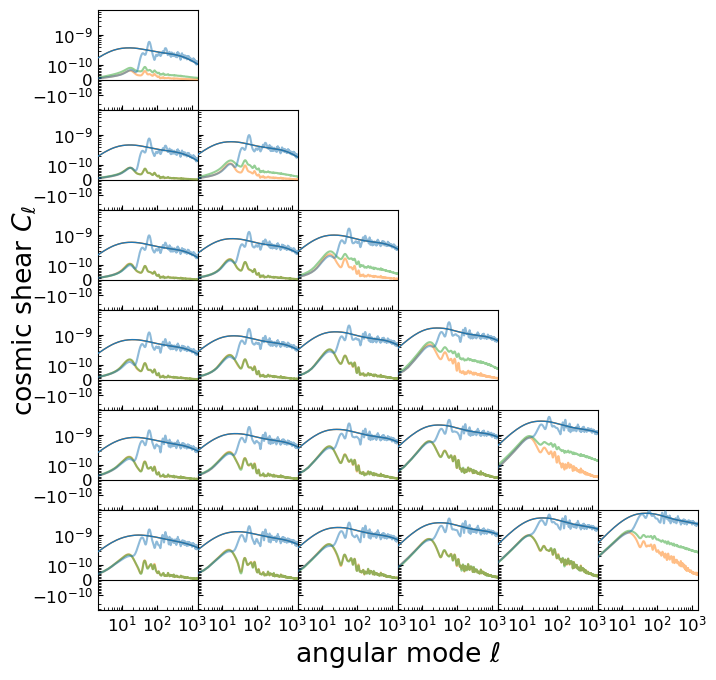

In [62]:
fig, ax = plt.subplots(6, 6, figsize=(6, 6), sharex=True, sharey=True)

for i in range(1, 7):
    for j in range(1, i):
        ax[j - 1, i - 1].axis("off")
    for j in range(i, 7):
        ax[j - 1, i - 1].plot(
            l[2:],
            l[2:]*tr1_cls_m["SHE", "SHE", i, j][0, 0, 2:],
            c="C0",
            lw=1.5,
            zorder=3.0,
            alpha=0.5,
        )
        ax[j - 1, i - 1].plot(
            l[2:], fsky*l[2:]*theory_cls[f"W{i}xW{j}"][2:], c="C0", lw=1.0, zorder=4.0
        )
        ax[j - 1, i - 1].plot(
            l[2:],
            l[2:]*tr1_cls_m["SHE", "SHE", i, j][1, 1, 2:],
            c="C1",
            lw=1.5,
            zorder=1.0,
            alpha=0.5,
        )
        ax[j - 1, i - 1].plot(
            l[2:],
            l[2:]*tr1_cls_wb_m["SHE", "SHE", i, j][1, 1, 2:],
            c="C2",
            ls='-',
            lw=1.5,
            zorder=1.0,
            alpha=0.5,
        )
        ax[j - 1, i - 1].plot(
            l[2:], fsky*l[2:]*theory_cls[f"W{i}xW{j}"][2:], c="C1", lw=1.0, zorder=2.0
        )
        ax[j - 1, i - 1].axhline(0.0, c="k", lw=0.8, zorder=-1)
        ax[j - 1, i - 1].tick_params(axis="both", which="both", direction="in")

ax[0, 0].set_xscale("log")
ax[0, 0].set_xlim(2, lmax_full) #lmax_full * 3)
ax[0, 0].xaxis.get_major_locator().set_params(numticks=99)
ax[0, 0].xaxis.get_minor_locator().set_params(
    numticks=99, subs=np.arange(0.1, 1.0, 0.1)
)
ax[0, 0].set_yscale(
    "symlog", linthresh=1e-10, linscale=0.45, subs=np.arange(0.1, 1.0, 0.1)
)
#ax[0, 0].set_ylim(-1e-8, 1e-6)

fig.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=1.0, wspace=0.0, hspace=0.0)

fig.supxlabel("angular mode $\\ell$", y=-0.05, va="top")
fig.supylabel("cosmic shear $C_\\ell$", x=-0.1, ha="right")

plt.show()

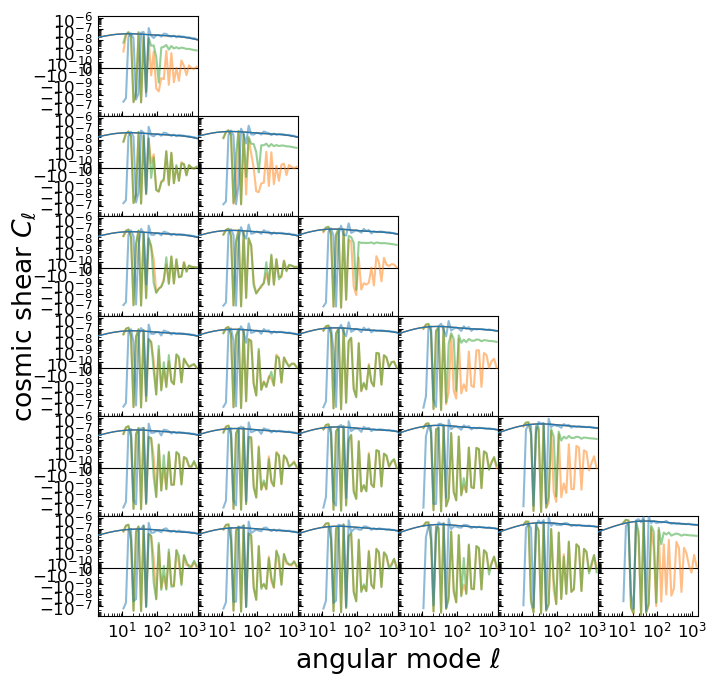

In [67]:
fig, ax = plt.subplots(6, 6, figsize=(6, 6), sharex=True, sharey=True)

for i in range(1, 7):
    for j in range(1, i):
        ax[j - 1, i - 1].axis("off")
    for j in range(i, 7):
        ax[j - 1, i - 1].plot(
            lgrid,
            lgrid*tr1_nu_cqs_m["SHE", "SHE", i, j][0, 0, :],
            c="C0",
            lw=1.5,
            zorder=3.0,
            alpha=0.5,
        )
        ax[j - 1, i - 1].plot(
            l[2:], l[2:]*theory_cls[f"W{i}xW{j}"][2:], c="C0", lw=1.0, zorder=4.0
        )
        ax[j - 1, i - 1].plot(
            lgrid,
            lgrid*tr1_nu_cqs_m["SHE", "SHE", i, j][1, 1, :],
            c="C1",
            lw=1.5,
            zorder=1.0,
            alpha=0.5,
        )
        ax[j - 1, i - 1].plot(
            lgrid,
            lgrid*tr1_nu_cqs_wb_m["SHE", "SHE", i, j][1, 1, :],
            c="C2",
            ls='-',
            lw=1.5,
            zorder=1.0,
            alpha=0.5,
        )
        ax[j - 1, i - 1].plot(
            l[2:], l[2:]*theory_cls[f"W{i}xW{j}"][2:], c="C1", lw=1.0, zorder=2.0
        )
        ax[j - 1, i - 1].axhline(0.0, c="k", lw=0.8, zorder=-1)
        ax[j - 1, i - 1].tick_params(axis="both", which="both", direction="in")

ax[0, 0].set_xscale("log")
ax[0, 0].set_xlim(2, lmax_full) #lmax_full * 3)
ax[0, 0].xaxis.get_major_locator().set_params(numticks=99)
ax[0, 0].xaxis.get_minor_locator().set_params(
    numticks=99, subs=np.arange(0.1, 1.0, 0.1)
)
ax[0, 0].set_yscale(
    "symlog", linthresh=1e-10, linscale=0.45, subs=np.arange(0.1, 1.0, 0.1)
)
#ax[0, 0].set_ylim(-1e-8, 1e-6)

fig.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=1.0, wspace=0.0, hspace=0.0)

fig.supxlabel("angular mode $\\ell$", y=-0.05, va="top")
fig.supylabel("cosmic shear $C_\\ell$", x=-0.1, ha="right")

plt.show()